# The t-Distribution <hr style = "border:2.5px solid #0000FF"></hr>

<b> Jehan Jedd Chavez </b>
<br> Comptech Student T09

In [58]:
#import and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from scipy import stats

In [59]:
df=pd.read_csv(r"dataset/transformer-voltage-10-sample.csv",
               delimiter=",",
                index_col="Sample")
df

,Voltage
Sample,
1,118.3
2,119.2
3,119.7
4,119.5
5,120.0
6,120.1
7,120.2
8,120.8
9,121.5


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 1 to 10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  10 non-null     float64
dtypes: float64(1)
memory usage: 160.0 bytes


In [61]:
df.describe()

,Voltage
count,10.000000
mean,120.110000
std,1.050344
min,118.300000
25%,119.550000
50%,120.050000
75%,120.650000
max,121.800000


In [62]:
alpha=0.05
n=df['Voltage'].count()

t_critical = stats.t.ppf(1-alpha/2,n-1)
t_critical

np.float64(2.2621571628540993)

In [63]:
#confidence interval
n=df['Voltage'].count()
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

ci_lower, ci_upper = stats.t.interval(
    confidence = 0.95,
    df=n-1,
    loc = mean,
    scale= std/np.sqrt(n)
)
print(f"CI:[{ci_lower:.2f},{ci_upper:.2f}]")

CI:[119.36,120.86]


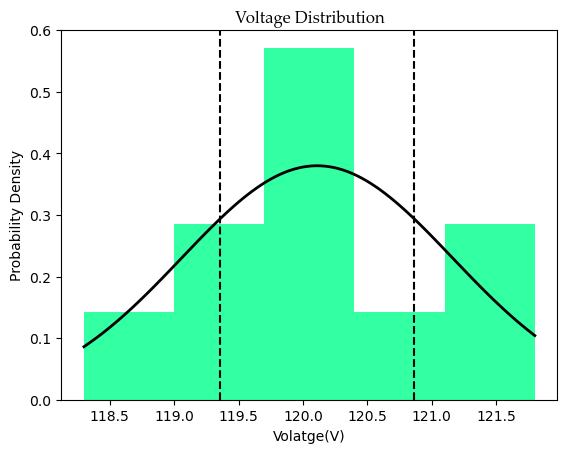

In [64]:
#Voltage distribution
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

#x-axis
x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

#normal distribution plot
x= np.linspace(x_min,x_max,100)
p = stats.norm.pdf(x,mean,std)




plt.plot(x,p,
         color="#000000",
         linewidth=2,
        )

#histogram
plt.hist(df['Voltage'], bins= 5,
         density=True,
         color="#00FF8C",
         alpha=0.8,
        )

plt.title('Voltage Distribution',
          font='Palatino Linotype',
          fontsize=12)
plt.xlabel('Volatge(V)')
plt.ylabel('Probability Density')


#confidence interval
plt.axvline(x=ci_lower,
            color='black',
            linestyle = '--')
plt.axvline(x=ci_upper,
            color='black',
            linestyle = '--')
plt.show()

## SHOE INVENTORY

In [65]:
df=pd.read_csv(r"dataset/shoe-inventory.csv",
                delimiter=",")
df

,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10


In [66]:
#(rows,columns)
df.shape

(17, 13)

In [67]:
mean_size_6 = df.iloc[0,1:13].mean()#exclude column
mean_size_6

np.float64(2.9166666666666665)

In [68]:
#std of size 6
std_size_6 = df.iloc[0,1:13].std()
print(f'std_size_6={std_size_6:.2f}')

std_size_6=1.78


In [69]:
#size 6 6 95% CI
n=df.shape[1]-1 #returns 13 in (17,13)

lower_6, upper_6 = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=mean_size_6,
    scale= std_size_6/np.sqrt(n)
)
print(f"CI:[{lower_6:.2f}, {upper_6:.2f}]")

CI:[1.78, 4.05]


In [ ]:
#95% confidence level
mean=df.iloc[0:17,1:13].mean(axis=1) # all 16 sizes
std=df.iloc[0:17,1:13].std(axis=1)

df['ci_lower'], df['ci_upper'] = stats.t.interval(
    confidence=0.95,
    df= n-1,
    loc=mean,
    scale= std/np.sqrt(n)
)
df

c:\Users\User\anaconda3\anaconda4\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\User\anaconda3\anaconda4\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,ci_lower,ci_upper
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0,1.784666,4.048667
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1,0.445009,2.888324
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0,0.330237,3.003096
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1,1.638094,4.695240
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6,4.139885,8.026782
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6,8.279920,13.220080
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10,14.499984,23.166683
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26,24.946583,35.720084
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20,19.300389,26.199611
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10,14.573064,20.593603


In [ ]:
#fill NAN with 0
df['ci_lower']= df['ci_lower'].fillna(0)
df['ci_upper']= df['ci_upper'].fillna(0)

In [72]:
df['ci_lower']= df['ci_lower'].astype(int).round()
df['ci_upper']= df['ci_upper'].astype(int).round()

In [75]:
#reommend no. of shoe pairs by size
df[['Size','ci_upper']]

,Size,ci_upper
0,6.0,4
1,6.5,2
2,7.0,3
3,7.5,4
4,8.0,8
5,8.5,13
6,9.0,23
7,9.5,35
8,10.0,26
9,10.5,20
